# NASA randomized and recommissioned battery dataset

An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions:

The dataset repository is organized into three main folders, each containing one group of life cycled battery packs. 
Within each folder individual battery packs own their dedicated csv file for continuous data logging, which are named with their respective battery pack number.

The folders are named: 

- regular_alt_batteries: Containing one csv file for each battery pack cycled at the same load level or load range throughout lifetime
- recommissioned_batteries: Containing one csv file for each battery pack cycled at different load levels at varying life stages
- second_life_batteries: Containing one csv file for each second life battery pack cycled at constant current througout the second life 

The columns in each csv file contain the following data with the provided units: 

The following columns contain data throughout the cycling process: 

- start time: [mm:dd:yyyy hh:mm:ss] (start time of each cycle day for each battery pack, in most cases approximately 24h)
- relative time: [s] (the relative time is continuous from the beginning of the entire life cycle to the failure of each battery pack)
- mode: -1 = discharge, 0 = rest, 1 = charge
- voltage charger: [V] (continuous battery pack voltage measurement right after the connection of the battery pack to the charger board)
- temperature battery: [C] (continuous temperature measurement on the battery cell electrode surface)

Those columns only contain data when the respective battery is connected to the load board and performing a discharge mission

- voltage load: [V] (battery pack voltage measured on the load board)
- current load: [A] (discharge current measured on the load board using current sense resistors)
- temperature mosfet: [C] (temperature on the load board mosfets, measured for safety purposes)
- temperature resistor: [C] (temperature on the load board current sense resistor, measured for safety purposes)
- mission type: 0 = reference discharge (constant current at 2.5A), 1 = regular mission

Please cite this dataset using:

```
@misc{2023_alt_dataset_fricke_et_al,
	Author = {Kajetan Fricke and Renato G. Nascimento and Felipe A. C. Viana},
	Doi = {},
	Howpublished = {},
	Month = {July},
	Publisher = {nasa-data@lists.arc.nasa.gov},
	Title = {An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions},
	Url = {},
	Version = {0.0.1},
	Year = {2023}}
```

The corresponding reference entry should look like: 
An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions, v0.0.1, 

### Publications

The following publications out of the PML-UCF research group used/referred to this repository:
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[Prognosis of Li-ion Batteries Under Large Load Variations Using Hybrid Physics-Informed Neural Networks]"
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions]"


## Regular accelerated life test (regular alt batteries folder):

This folder contains the data files from battery packs subject to constant and variable loading conditions, 
where the current range of the latter remains the same throughout the battery life.

The assigned battery packs in this folder are numbered as
follows:

– Constant current:
Those battery packs were subjected to the same load level during discharge missions over their respective life time.

The here provided averaged current levels are approximated, and might vary slightly:

* 9.30A: Battery pack 0.1 and 1.1
* 12.9A: Battery pack 3.1 and 2.2
* 14.3A: Battery pack 2.3 and 5.2
* 16.0A: Battery pack 0.0 and 1.0
* 19.0A: Battery pack 2.0, 3.0 and 2.1

– Variable current:

Those battery packs are subjected to variable current within a discharge cycle.
The current level segments are kept constant for either 40, 60 or 80 seconds before switching to another level.
Both, the amplitude and length of each current level segments was randomly selected to create a pool of different random loading discharge missions.

The here provided averaged current levels are approximated, and might vary slightly:

* 14.3A average (12.9A - 16A range): Battery pack 4.1 and 5.1
* 17.0A average (16A - 19A range): Battery pack 4.0 and 5.0


## Recommissioned batteries (recommissioned batteries folder):

This folder contains the data files from battery packs where the constant loading conditions were changed throughout the battery life. 
The assigned battery packs in this folder are numbered as follows:

– Two life stages:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching an capacity level of approximately 2.2Ah,
and then switched to the second current level until reaching end of life

The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A: Battery pack 3.2
* 14.3A, 16A: Battery pack 5.3
* 16A, 12.9A: Battery pack 0.2 and 3.3
* 16A, 9.30A: Battery pack 1.2 and 2.4

– Three life stages:
Those batteries were subjected to current level switches at approximately 2.2Ah and 2.0Ah of capacity.
The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A, 7.5A: Battery pack 0.3
* 16A, 7.5A, 14.3A: Battery pack 2.5


## Second life batteries (second life batteries folder):

This folder contains the data files from battery packs that consist of battery cells survived from previously cycled battery packs. 
The assigned battery packs in this folder are numbered as follows:

– 2nd life battery packs:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching end of life (EOL).
Survivor cells were then reused and subjected to the second provided current level until reaching EOL

The here provided averaged current levels are approximated, and might vary slightly:

* 16.0A, 9.3A: Battery pack 1.3 (First life battery packs: 0.0 & 1.1)
* 14.3A, 7.5A: Battery pack 3.6 (First life battery packs: 2.3 & 5.2)
* 12.9A, 5.0A: Battery pack 5.4 (First life battery packs: 2.2 & 3.1)

## Machine Learning

### Train-Test-Split

In [1]:
import pandas as pd
import numpy as np

batt_labels = ['battery00','battery01','battery10','battery11','battery20','battery21','battery22',\
              'battery23','battery30','battery31','battery40','battery41','battery50','battery51','battery52',\
              'battery02','battery03','battery12','battery24','battery25','battery32','battery33','battery53']

complete_df = pd.read_csv("data_complete.csv")

np.random.seed(45)#

train_labels = np.random.choice(
    batt_labels,
    size=17,
    replace=False
)

print(train_labels)
test_labels = list(set(batt_labels) - set(train_labels))
print(test_labels)

train_df = pd.DataFrame([])
test_df = pd.DataFrame([])

for label in train_labels:
    train_df = pd.concat([train_df,complete_df[complete_df['batt_label']==label]],axis=0)

for label in test_labels:
    test_df = pd.concat([test_df,complete_df[complete_df['batt_label']==label]],axis=0)

['battery50' 'battery25' 'battery03' 'battery51' 'battery32' 'battery40'
 'battery10' 'battery24' 'battery12' 'battery53' 'battery23' 'battery30'
 'battery22' 'battery31' 'battery21' 'battery52' 'battery01']
['battery33', 'battery00', 'battery20', 'battery41', 'battery02', 'battery11']


In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

all_mae = {}

def train_gradient_boost(target, feature_set):
    y_train = train_df[target]
    y_test = test_df[target]
    
    if len(feature_set) == 1:
        X_train = np.array(train_df[feature_set[0]]).reshape(-1,1)
        X_test = np.array(test_df[feature_set[0]]).reshape(-1,1)
    else:
        X_train = train_df[feature_set]
        X_test = test_df[feature_set]

    gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=10,
                                 learning_rate=0.5, random_state=42)

    gbrt.fit(X_train, y_train)
    
    
    gbrt_best = GradientBoostingRegressor(
        max_depth=2, learning_rate=0.05, n_estimators=5000,
        n_iter_no_change=10, random_state=42)
    gbrt_best.fit(X_train, y_train)

    print(f"Anzahl Estimators bei Gradient Boost mit bester Vorhersage: {gbrt_best.n_estimators_}")

    if len(feature_set) != 1:   
        importance = gbrt_best.feature_importances_
        feature_names = X_train.columns
        
        feat_imp = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        })
        
        feat_imp = feat_imp.sort_values(
            by="Importance",
            ascending=False
        )
        
        print(feat_imp)
    
    
    y_test_predict_gbrt = gbrt.predict(X_test)
    y_test_predict_gbrt_best = gbrt_best.predict(X_test)
    
    test_mae_gbrt = mean_absolute_error(y_test,y_test_predict_gbrt)
    test_mae_gbrt_best = mean_absolute_error(y_test,y_test_predict_gbrt_best)
    print(f"Mean absolute error Gradient boost with 10 estimators: {test_mae_gbrt}")
    print(f"Mean absolute error Gradient boost with {gbrt_best.n_estimators_} estimators: {test_mae_gbrt_best}")
    return test_mae_gbrt, test_mae_gbrt_best, gbrt, gbrt_best

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions(model=None, data=None, feature=None, target=None):
    ma = data[feature].max()
    x1 = np.linspace(0, ma*1.1, 500)
    fig, axes = plt.subplots(ncols=1, figsize=(10, 4), sharey=True)
    if model != None:
        y_pred = model.predict(x1.reshape(-1,1))
        plt.plot(x1, y_pred, "r-", linewidth=2, label='model')
        plt.title(f"learning_rate={model.learning_rate}, n_estimators={model.n_estimators_}")
        
    sns.scatterplot(data=data, x=feature, y=target, hue='batt_label')

    plt.xlabel(feature)
    plt.ylabel(target, rotation=0)
    plt.show()

### Nur Q_norm_at_3.6V Feature

In [4]:
mae, mae_best, model, best_model = train_gradient_boost("SOH", ['Q_norm_at_3.6_V'])
all_mae["Q_norm_at_3.6V Feature"] = {}
all_mae["Q_norm_at_3.6V Feature"]["base_mae"] = mae
all_mae["Q_norm_at_3.6V Feature"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 121
Mean absolute error Gradient boost with 10 estimators: 1.1546578681576023
Mean absolute error Gradient boost with 121 estimators: 1.0784351561429482


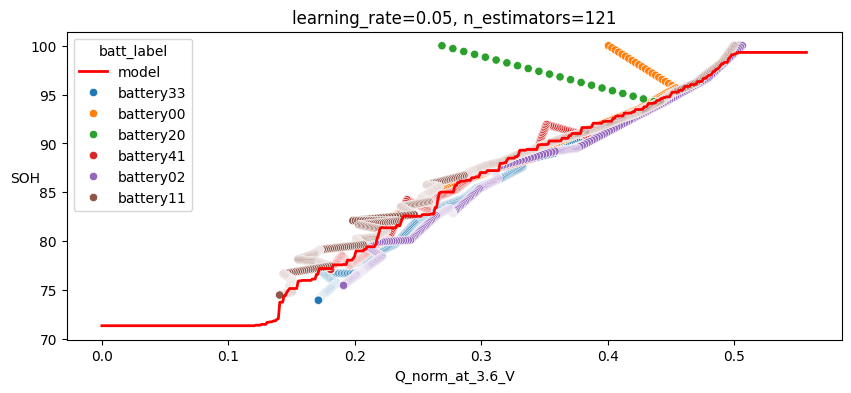

In [5]:
plot_predictions(best_model, test_df, 'Q_norm_at_3.6_V', "SOH")

### Feature Set Q_norm

In [6]:
mae, mae_best, model, best_model = train_gradient_boost("SOH", ['Q_norm_at_3.6_V', 'Q_norm_at_3.7_V','Q_norm_at_3.8_V', 'Q_norm_at_3.9_V'])
all_mae["Q_norm Features"] = {}
all_mae["Q_norm Features"]["base_mae"] = mae
all_mae["Q_norm Features"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 926
           Feature  Importance
0  Q_norm_at_3.6_V    0.923925
1  Q_norm_at_3.7_V    0.041641
3  Q_norm_at_3.9_V    0.024298
2  Q_norm_at_3.8_V    0.010137
Mean absolute error Gradient boost with 10 estimators: 1.214329763834257
Mean absolute error Gradient boost with 926 estimators: 1.008818985227779


### Feature Set mit Q_norm_at_3.9V, Q_norm_at_3.8V

In [7]:
mae, mae_best, model, best_model = train_gradient_boost("SOH", ['Q_norm_at_3.8_V', 'Q_norm_at_3.9_V'])
all_mae["Q_norm_at_3.8V, Q_norm_at_3.9V Features"] = {}
all_mae["Q_norm_at_3.8V, Q_norm_at_3.9V Features"]["base_mae"] = mae
all_mae["Q_norm_at_3.8V, Q_norm_at_3.9V Features"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 362
           Feature  Importance
0  Q_norm_at_3.8_V    0.937216
1  Q_norm_at_3.9_V    0.062784
Mean absolute error Gradient boost with 10 estimators: 1.8885587034854694
Mean absolute error Gradient boost with 362 estimators: 1.710684620729476


### Komplettes Feature Set ohne Q_norm

In [8]:
drop_features = ['batt_label','isRefCycle','SOH','RUL_EFC','Q_norm_at_3.6_V','Q_norm_at_3.7_V','Q_norm_at_3.8_V','Q_norm_at_3.9_V']
all_features = train_df.columns
train_features = list(set(all_features) - set(drop_features))
mae, mae_best, model, best_model = train_gradient_boost("SOH", train_features)
all_mae["Complete Feature Set without Q_norm"] = {}
all_mae["Complete Feature Set without Q_norm"]["base_mae"] = mae
all_mae["Complete Feature Set without Q_norm"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 1501
                              Feature    Importance
39   integral_low_volt_high_discharge  7.688938e-01
0   integral_high_temp_high_discharge  7.892471e-02
24                 sec_at_low_voltage  4.501564e-02
33                     sec_C_rate_6_8  3.030490e-02
35                        sec_T_30_45  1.606938e-02
15                             R_mOhm  1.284332e-02
31                          T_cum_min  1.142176e-02
38                       sec_T_60_100  7.948316e-03
7                      C_rate_cum_max  5.793005e-03
12                     sec_C_rate_4_6  4.516019e-03
17                          T_cum_avg  4.461548e-03
30                      sec_T_over_45  3.126077e-03
1                       sec_T_over_50  2.056463e-03
34                     sec_C_rate_3_4  1.235466e-03
36                     sec_C_rate_1_2  1.168014e-03
10        integral_low_volt_high_temp  1.088828e-03
29                          T_cum_max  8.730396e-04

### Feature set with one integral

In [9]:
mae, mae_best, model, best_model = train_gradient_boost("SOH", ['integral_low_volt_high_discharge'])
all_mae["integral_low_volt_high_discharge Feature"] = {}
all_mae["integral_low_volt_high_discharge Feature"]["base_mae"] = mae
all_mae["integral_low_volt_high_discharge Feature"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 98
Mean absolute error Gradient boost with 10 estimators: 1.1938915845711608
Mean absolute error Gradient boost with 98 estimators: 1.128999400891523


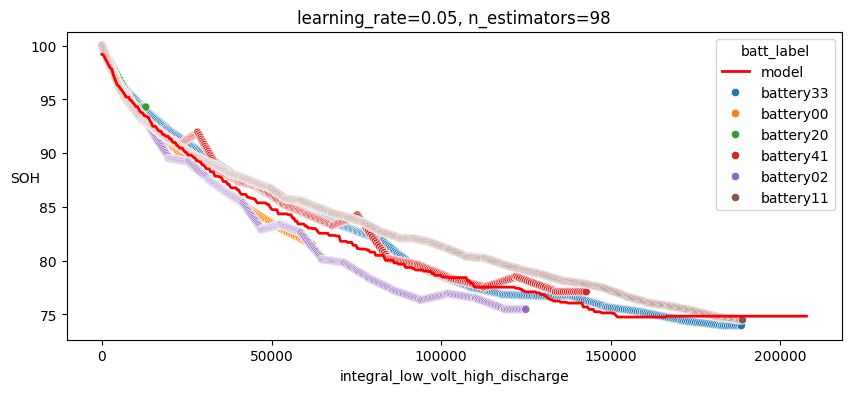

In [10]:
plot_predictions(best_model, test_df, 'integral_low_volt_high_discharge', "SOH")

### Feature set only with all integrals

In [11]:
mae, mae_best, model, best_model = train_gradient_boost("SOH", ['integral_low_volt_high_discharge','integral_low_volt_high_temp','integral_high_temp_high_discharge'])
all_mae["all integral Features"] = {}
all_mae["all integral Features"]["base_mae"] = mae
all_mae["all integral Features"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 812
                             Feature  Importance
0   integral_low_volt_high_discharge    0.878093
2  integral_high_temp_high_discharge    0.101075
1        integral_low_volt_high_temp    0.020832
Mean absolute error Gradient boost with 10 estimators: 1.137757432687114
Mean absolute error Gradient boost with 812 estimators: 1.2838155223688998


### Feature-Set R_mOhm and C_rate_cycle_max

In [12]:
mae, mae_best, model, best_model = train_gradient_boost("SOH",['R_mOhm','C_rate_cycle_max'])
all_mae["R_mOhm, C_rate_cylcle_max Features"] = {}
all_mae["R_mOhm, C_rate_cylcle_max Features"]["base_mae"] = mae
all_mae["R_mOhm, C_rate_cylcle_max Features"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 706
            Feature  Importance
0            R_mOhm    0.797227
1  C_rate_cycle_max    0.202773
Mean absolute error Gradient boost with 10 estimators: 3.0487054852179023
Mean absolute error Gradient boost with 706 estimators: 2.7855099485875154


In [13]:
mae, mae_best, model, best_model = train_gradient_boost("SOH",\
['sec_C_rate_0_0.5', 'sec_C_rate_0.5_1', 'sec_C_rate_1_2', 'sec_C_rate_2_3', 'sec_C_rate_3_4',\
 'sec_C_rate_4_6', 'sec_C_rate_6_8', 'sec_C_rate_gt_8'])
all_mae["C rate Histogramm Features"] = {}
all_mae["C rate Histogramm Features"]["base_mae"] = mae
all_mae["C rate Histogramm Features"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 1529
            Feature  Importance
2    sec_C_rate_1_2    0.738509
6    sec_C_rate_6_8    0.147691
0  sec_C_rate_0_0.5    0.070648
5    sec_C_rate_4_6    0.033223
4    sec_C_rate_3_4    0.004027
7   sec_C_rate_gt_8    0.003857
3    sec_C_rate_2_3    0.002045
1  sec_C_rate_0.5_1    0.000000
Mean absolute error Gradient boost with 10 estimators: 1.7911757838367728
Mean absolute error Gradient boost with 1529 estimators: 1.666040794674421


### T Histogramm Feature Set

In [14]:
mae, mae_best, model, best_model = train_gradient_boost("SOH",['sec_T_15_30','sec_T_30_45','sec_T_45_60','sec_T_60_100','sec_T_gt_100'])
all_mae["T Histogramm Features"] = {}
all_mae["T Histogramm Features"]["base_mae"] = mae
all_mae["T Histogramm Features"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 2300
        Feature  Importance
1   sec_T_30_45    0.678157
3  sec_T_60_100    0.247836
2   sec_T_45_60    0.048730
0   sec_T_15_30    0.024176
4  sec_T_gt_100    0.001102
Mean absolute error Gradient boost with 10 estimators: 2.441809306650226
Mean absolute error Gradient boost with 2300 estimators: 4.101108249920536


### Feature set t(T > X°C)

In [15]:
mae, mae_best, model, best_model = train_gradient_boost("SOH",['sec_T_over_45'])
all_mae["sec_T_over_45 Feature"] = {}
all_mae["sec_T_over_45 Feature"]["base_mae"] = mae
all_mae["sec_T_over_45 Feature"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 86
Mean absolute error Gradient boost with 10 estimators: 1.4436099861862328
Mean absolute error Gradient boost with 86 estimators: 1.386419485312226


In [16]:
mae, mae_best, model, best_model = train_gradient_boost("SOH",['sec_T_over_40'])
all_mae["sec_T_over_40 Feature"] = {}
all_mae["sec_T_over_40 Feature"]["base_mae"] = mae
all_mae["sec_T_over_40 Feature"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 89
Mean absolute error Gradient boost with 10 estimators: 1.926036315897128
Mean absolute error Gradient boost with 89 estimators: 1.8737875634238033


In [17]:
mae, mae_best, model, best_model = train_gradient_boost("SOH",['sec_T_over_50'])
all_mae["sec_T_over_50 Feature"] = {}
all_mae["sec_T_over_50 Feature"]["base_mae"] = mae
all_mae["sec_T_over_50 Feature"]["best_mae"] = mae_best

Anzahl Estimators bei Gradient Boost mit bester Vorhersage: 98
Mean absolute error Gradient boost with 10 estimators: 2.9975272063910237
Mean absolute error Gradient boost with 98 estimators: 2.941378527178201


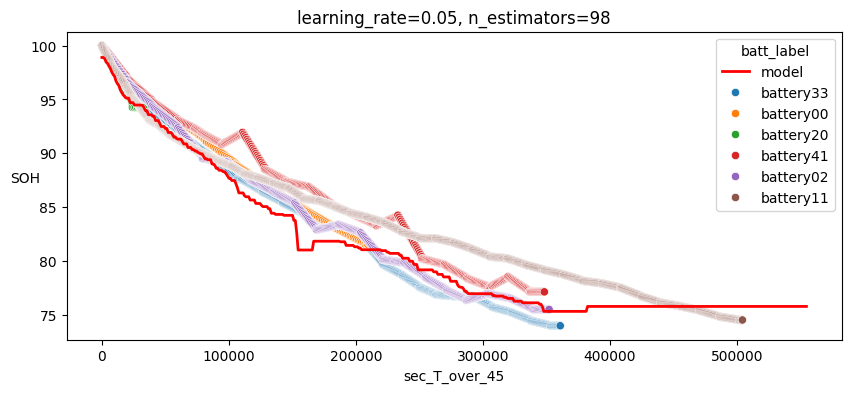

In [18]:
plot_predictions(best_model, test_df, 'sec_T_over_45', "SOH")

### Zusammenfassung Machine Learning SOH

#### Gradient Boost

In [19]:
all_mae_df = pd.DataFrame(all_mae)
all_mae_df

,Q_norm_at_3.6V Feature,Q_norm Features,"Q_norm_at_3.8V, Q_norm_at_3.9V Features",Complete Feature Set without Q_norm,integral_low_volt_high_discharge Feature,all integral Features,"R_mOhm, C_rate_cylcle_max Features",C rate Histogramm Features,T Histogramm Features,sec_T_over_45 Feature,sec_T_over_40 Feature,sec_T_over_50 Feature
base_mae,1.154658,1.214330,1.888559,1.290011,1.193892,1.137757,3.048705,1.791176,2.441809,1.443610,1.926036,2.997527
best_mae,1.078435,1.008819,1.710685,0.995266,1.128999,1.283816,2.785510,1.666041,4.101108,1.386419,1.873788,2.941379
